Adding physical features 

# Load Data

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from utils.data_loader import load_parquet

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay', '|avg B|', 'F10.7 (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 4)
                 time  orbital_decay   |avg B|  F10.7 (LASP)
0 2023-01-01 00:00:00        16.6730  5.630000         153.0
1 2023-01-01 00:00:20        16.6730  5.633333         153.0
2 2023-01-01 00:00:40        16.6735  5.636667         153.0
3 2023-01-01 00:01:00        16.6740  5.640000         153.0
4 2023-01-01 00:01:20        16.6740  5.633333         153.0


# 1. Select a subset

In [3]:
from utils.plot_loader import create_subset
# =========================== Input ===================================
start_date = '2024-04-26 00:00:00'
end_date = '2024-05-04 00:00:00'
# =====================================================================

subset = create_subset(GFOC_data, start_date, end_date)
time = subset['time'].values
# make 'time' the index
subset.set_index('time', inplace=True)

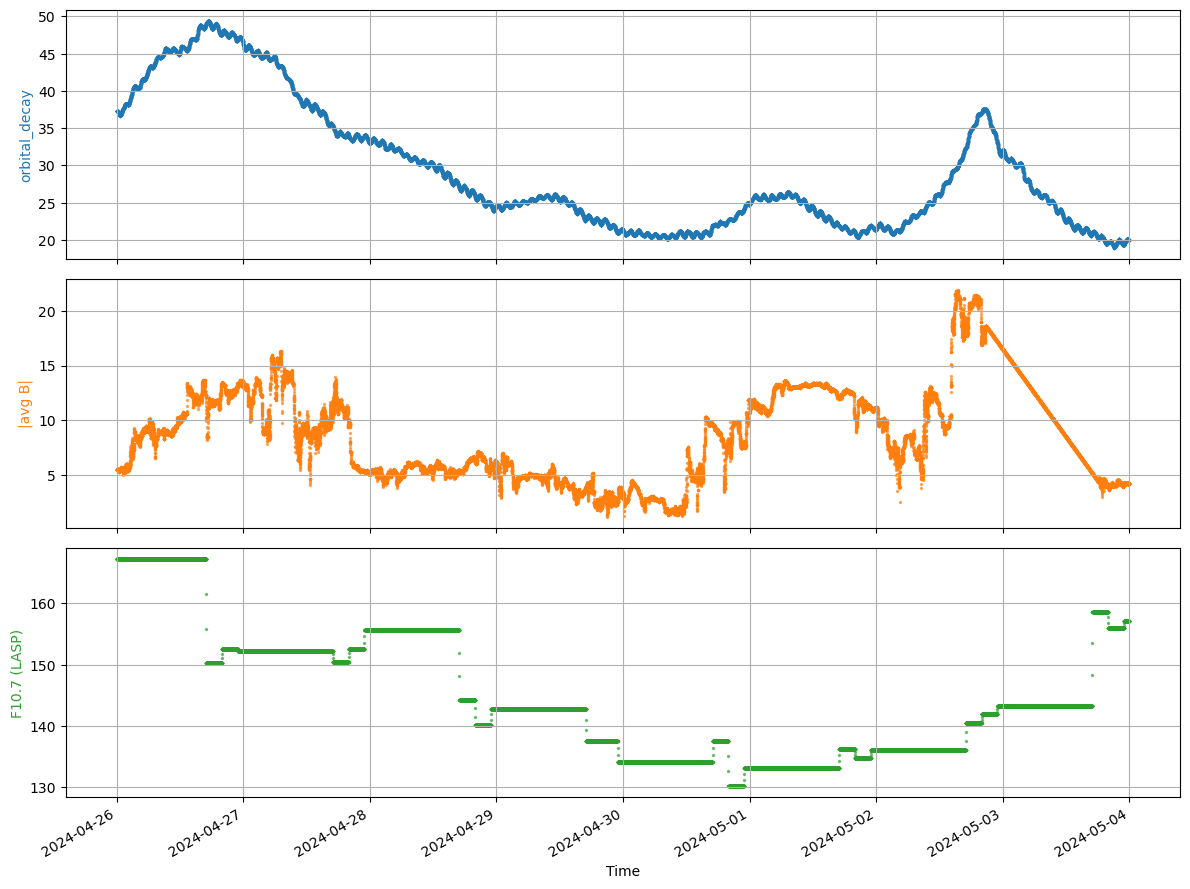

In [4]:
# plot all features from columns_needed
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(subset.index, subset['orbital_decay'], s=2, c='C0', alpha=0.6)
axes[0].set_ylabel('orbital_decay', color='C0')
axes[0].grid(True)

axes[1].scatter(subset.index, subset['|avg B|'], s=2, c='C1', alpha=0.6)
axes[1].set_ylabel('|avg B|', color='C1')
axes[1].grid(True)

axes[2].scatter(subset.index, subset['F10.7 (LASP)'], s=2, c='C2', alpha=0.6)
axes[2].set_ylabel('F10.7 (LASP)', color='C2')
axes[2].set_xlabel('Time')
axes[2].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 2. Prepare Data

In [5]:
def make_lags(df, lag_config, lead_time=1):
    """
    Create lag features for multiple columns with customizable lag depth and step size per feature.

    Parameters
    ----------
    df : pd.DataFrame
        Input data containing the columns to lag.
    lag_config : dict
        Dictionary specifying the lag depth and step size per column.
        Example:
            lag_config = {
                'orbital_decay': {'lags': 10, 'step': 20},
                '|avg B|': {'lags': 3, 'step': 10},
                'F10.7 (LASP)': {'lags': 5, 'step': 60}
            }
    lead_time : int, default=1
        Minimum shift before the first lag (useful for forecasting ahead).

    Returns
    -------
    pd.DataFrame
        DataFrame containing all generated lagged features.
    """
    out = {}

    for col, params in lag_config.items():
        n_lags = params.get('lags', 1)
        step = params.get('step', 1)

        for i in range(lead_time, n_lags * step + lead_time, step):
            out[f"{col}_lag_{i}"] = df[col].shift(i)

    return pd.DataFrame(out)


def make_multistep_target(ts, steps):
    return pd.concat(
        {f'y_step_{i + 1}': ts.shift(-i)
         for i in range(steps)},
        axis=1)


lag_config = {
    'orbital_decay': {'lags': 100, 'step': 15},      # (we want at least one full orbital period 100min)
    '|avg B|': {'lags': 40, 'step': 100},            # (we want up to 50h)
    'F10.7 (LASP)': {'lags': 5, 'step': 10*60*3}     # (changes very slowly, so few lags at long intervals are fine)
}

# print lag config (convert steps/lag counts into seconds/minutes/hours assuming 20s sampling)
seconds_per_step = 20  # each row is 20 seconds

for col, params in lag_config.items():
    n_lags = int(params.get('lags', 1))
    step = int(params.get('step', 1))

    step_secs = step * seconds_per_step
    step_min = step_secs / 60
    max_secs = n_lags * step_secs
    max_min = max_secs / 60
    max_hr = max_min / 60

    print(
        f"{col}: n_lags={n_lags}, step={step} -> "
        f"step={step_min:.1f} min, "
        f"max_lag={max_hr:.1f} h"
    )


X = make_lags(subset, lag_config).fillna(0.0)

# n hour forecast (20 second intervals) for each point
n = 1
y = make_multistep_target(subset[['orbital_decay']].copy(), steps=n * 3 * 60).dropna()

# Shifting has created indexes that don't match. Only keep times for
# which we have both targets and features.
y, X = y.align(X, join='inner', axis=0)

# Rename columns to avoid MultiIndex issues
X.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in X.columns]
y.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in y.columns]

orbital_decay: n_lags=100, step=15 -> step=5.0 min, max_lag=8.3 h
|avg B|: n_lags=40, step=100 -> step=33.3 min, max_lag=22.2 h
F10.7 (LASP): n_lags=5, step=1800 -> step=600.0 min, max_lag=50.0 h


## Feature validation

<Axes: >

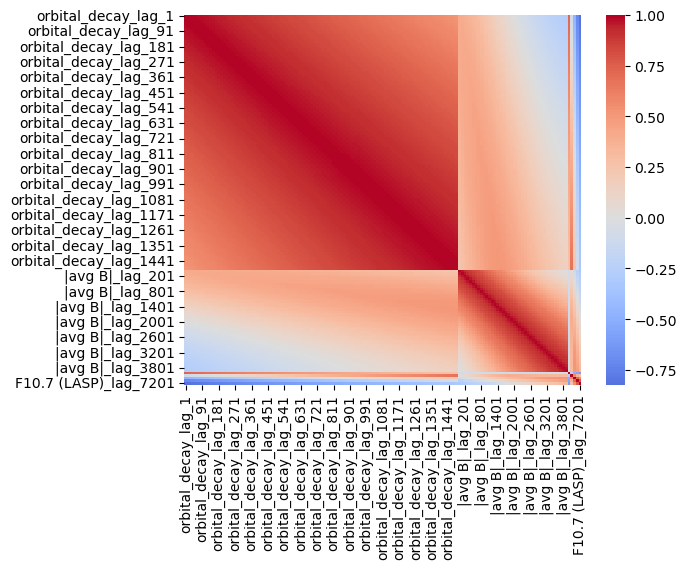

In [6]:
import seaborn as sns

corr = X.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)

In [7]:
from sklearn.linear_model import MultiTaskLasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mtlasso', MultiTaskLasso(alpha=1e-4))
])

# downsample for speed
# downsample for speed (time is the index)
X_down = X.resample('5min').mean().dropna()
y_down = y.resample('5min').mean().dropna()

pipe.fit(X_down, y_down)

/home/dschwarz/anaconda3/envs/mt_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:2712: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.122e+04, tolerance: 2.992e+03
  ) = cd_fast.enet_coordinate_descent_multi_task(


,steps,"[('scaler', ...), ('mtlasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,0.0001
,fit_intercept,True
,copy_X,True
,max_iter,1000


In [8]:
coef = pipe.named_steps['mtlasso'].coef_
importance = pd.Series(coef.mean(axis=0), index=X.columns).abs().sort_values(ascending=False)
print(importance.head(20))

orbital_decay_lag_1      9.001498
orbital_decay_lag_16     0.724456
|avg B|_lag_701          0.226861
|avg B|_lag_1            0.223096
|avg B|_lag_301          0.211146
|avg B|_lag_2301         0.210613
|avg B|_lag_2901         0.207972
|avg B|_lag_1001         0.205164
|avg B|_lag_401          0.191919
|avg B|_lag_801          0.185806
|avg B|_lag_3001         0.181194
|avg B|_lag_2701         0.176160
orbital_decay_lag_706    0.168465
|avg B|_lag_101          0.158678
|avg B|_lag_2601         0.156100
|avg B|_lag_3201         0.155661
|avg B|_lag_2501         0.149875
orbital_decay_lag_301    0.142675
|avg B|_lag_1801         0.142461
|avg B|_lag_3601         0.124992
dtype: float64


# 3. Multioutput Model

In [9]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train-test split (chronologically)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
# model = MultiOutputRegressor(XGBRegressor())
model.fit(X_train, y_train)

y_fit = pd.DataFrame(model.predict(X_train), index=X_train.index, columns=y.columns)
y_pred = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns)

/home/dschwarz/anaconda3/envs/mt_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


### Sanity check

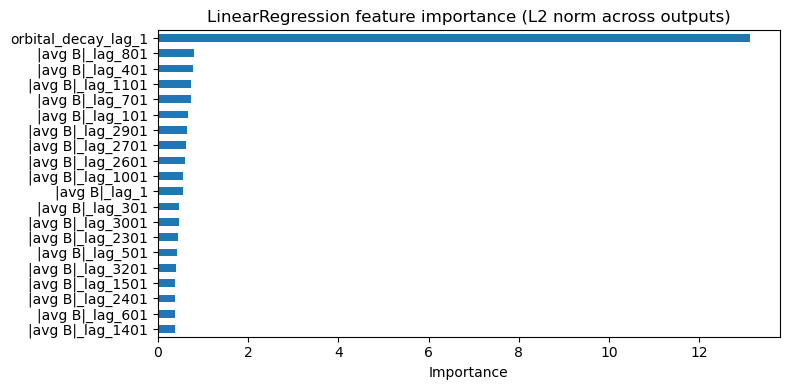

In [10]:
import numpy as np
import pandas as pd

# Feature importance for LinearRegression (handles multioutput)

# get coefficients (supports plain LinearRegression or MultiOutputRegressor-like wrappers)
if hasattr(model, "coef_"):
    coefs = model.coef_
elif hasattr(model, "estimators_"):
    # stack coefficients from wrapped estimators (e.g. MultiOutputRegressor)
    coefs = np.vstack([getattr(est, "coef_", np.zeros(len(X.columns))) for est in model.estimators_])
else:
    raise RuntimeError("Model does not expose coefficients via coef_ or estimators_")

# aggregate importance across outputs: use L2 norm across target dims
if coefs.ndim == 1:
    importance = np.abs(coefs)
else:
    importance = np.linalg.norm(coefs, axis=0)

imp_series = pd.Series(importance, index=X.columns).sort_values()

# only plot the top 20 features
imp_series = imp_series.tail(20)

fig, ax = plt.subplots(figsize=(8, max(4, len(imp_series) * 0.02)))
imp_series.plot.barh(ax=ax, color="C0")
ax.set_title("LinearRegression feature importance (L2 norm across outputs)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

Save model

In [11]:
# model_10_20 = model

## Results

In [12]:
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

simplefilter("ignore")

# Set Matplotlib defaults
plt.style.use("default")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def plot_multistep(y, every=1, ax=None, palette_kwargs=None):
    palette_kwargs_ = dict(palette='husl', n_colors=16, desat=None)
    if palette_kwargs is not None:
        palette_kwargs_.update(palette_kwargs)
    palette = sns.color_palette(**palette_kwargs_)
    if ax is None:
        fig, ax = plt.subplots()
    ax.set_prop_cycle(plt.cycler('color', palette))
    for date, preds in y[::every].iterrows():
        preds.index = pd.period_range(start=date, periods=len(preds), freq='20S')
        preds.plot(ax=ax, alpha=0.5)
    return ax

## Results

In [17]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

train_rmse = root_mean_squared_error(y_train, y_fit)
test_rmse = root_mean_squared_error(y_test, y_pred)
print((f"Train RMSE: {train_rmse:.3}\n" f"Test RMSE: {test_rmse:.3}"))
train_r2 = r2_score(y_train, y_fit)
test_r2 = r2_score(y_test, y_pred)
print((f"Train R2: {train_r2:.3}\n" f"Test R2: {test_r2:.3}"))

Train RMSE: 0.42
Test RMSE: 0.574
Train R2: 0.998
Test R2: 0.986


### Evolution of Error

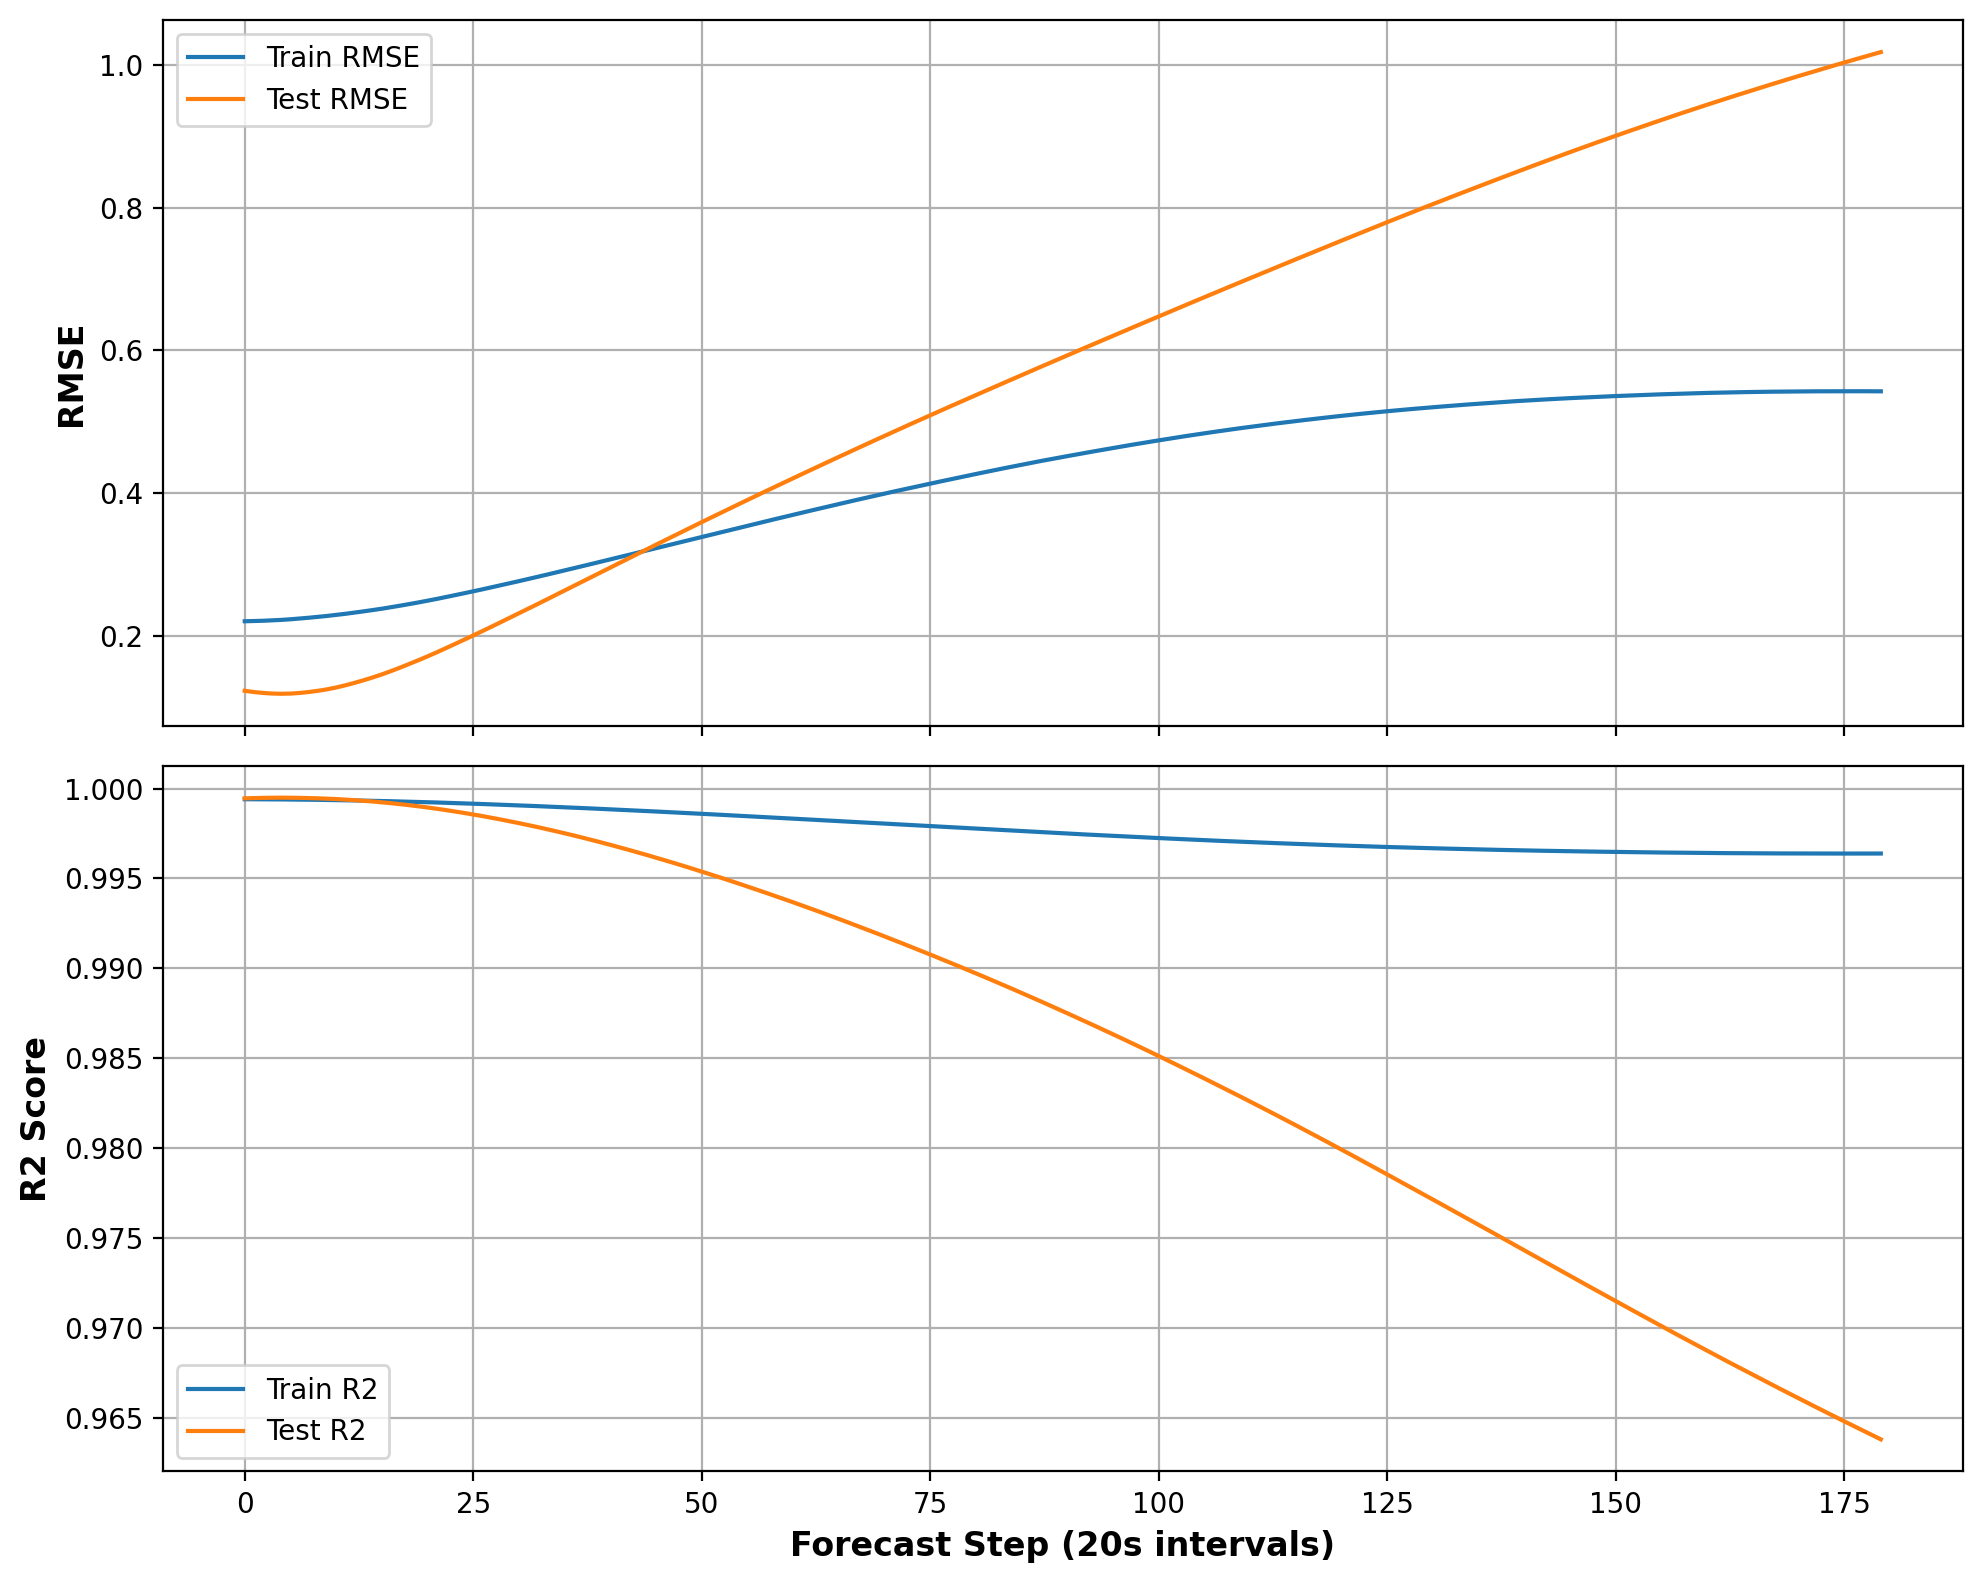

In [18]:
train_rmse_list = []
test_rmse_list = []
train_r2_list = []
test_r2_list = []

for i in range(len(y.columns)):
    train_rmse_list.append(root_mean_squared_error(y_train.iloc[:, i], y_fit.iloc[:, i]))
    test_rmse_list.append(root_mean_squared_error(y_test.iloc[:, i], y_pred.iloc[:, i]))
    train_r2_list.append(r2_score(y_train.iloc[:, i], y_fit.iloc[:, i]))
    test_r2_list.append(r2_score(y_test.iloc[:, i], y_pred.iloc[:, i]))

fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax[0].plot(train_rmse_list, label='Train RMSE')
ax[0].plot(test_rmse_list, label='Test RMSE')
ax[0].set_ylabel('RMSE')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(train_r2_list, label='Train R2')
ax[1].plot(test_r2_list, label='Test R2')
ax[1].set_ylabel('R2 Score')
ax[1].set_xlabel('Forecast Step (20s intervals)')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()

## Plot

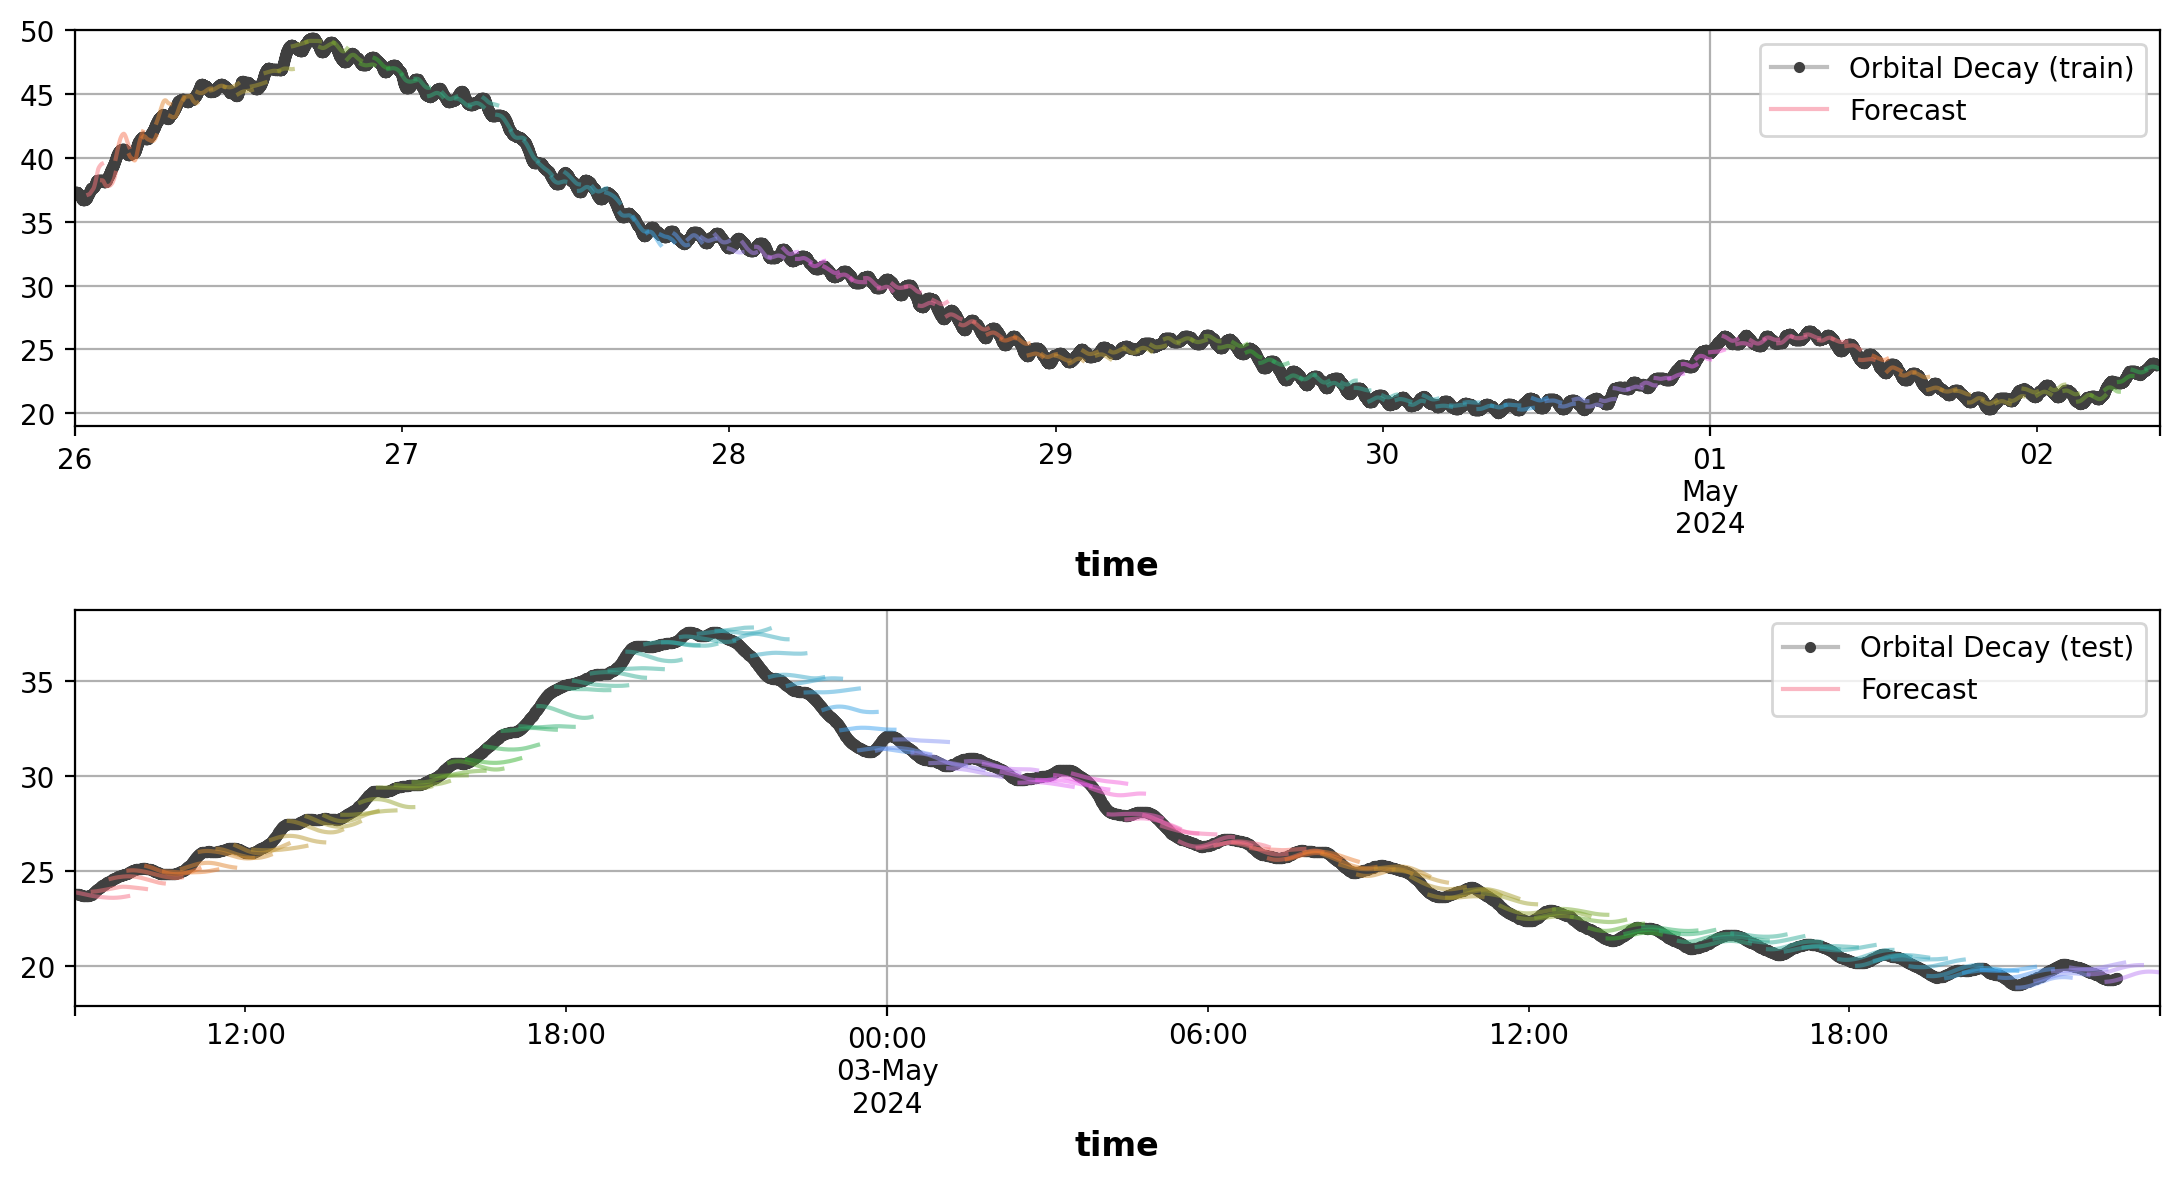

In [15]:

palette = dict(palette='husl', n_colors=64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1 = y_train.iloc[:,[0]].plot(**plot_params, ax=ax1)
ax1 = plot_multistep(y_fit, every=180, ax=ax1, palette_kwargs=palette)
_ = ax1.legend(['Orbital Decay (train)', 'Forecast'])
ax1.grid(True)
ax1.set_ylim(19,50)

ax2 = y_test.iloc[:,[0]].plot(**plot_params, ax=ax2)
ax2 = plot_multistep(y_pred, every=60, ax=ax2, palette_kwargs=palette)
_ = ax2.legend(['Orbital Decay (test)', 'Forecast'])
ax2.grid(True)
plt.tight_layout()
plt.show()


## Summary

- works much better with difference, but still not great.